# libKriging vs GPy (Python)

This notebook compares **pylibkriging** and **GPy** along two axes:

1. **Mimicry**: reproduce with `pylibkriging` a "default" Kriging fit
   equivalent to GPy's `GPRegression` (Matern 5/2 ARD kernel, constant
   mean, maximum likelihood), and check that both give near-identical
   predictions.
2. **Package-specific feature**: GPy's best-known contribution to scaling
   Gaussian processes is the **sparse/inducing-point approximation**
   (`SparseGPRegression`, Titsias 2009), which replaces the exact $O(n^3)$
   Gaussian process by a variational approximation built from a small set
   of $M \ll n$ inducing points, trading a controllable amount of accuracy
   for a much smaller compute/memory budget as the number of observations
   $n$ grows. `pylibkriging` itself is fast enough in plain, exact form
   that this is rarely needed at moderate $n$; its own answer to the same
   *"many observations"* scaling problem is architecturally different --
   `NestedKriging` partitions the training data and aggregates independent
   local Kriging experts. `NestedKriging` is not yet exposed through the
   Python binding, so we illustrate the same partition-and-aggregate idea
   directly with `pylibkriging.Kriging`, using a simple K-means split into
   independent submodels, and compare it against GPy's sparse GP.

Steps:
1. Check the Python environment (pylibkriging + GPy installed).
2. Load both packages.
3. Define the Branin test function and a Latin Hypercube design.
4. Mimicry: fit both packages' default Kriging on Branin 2D, compare
   hyperparameters and overlay predictions on 1D slices.
5. Special feature: fit a larger design (n=1500) with GPy's exact GP,
   GPy's sparse GP, plain `pylibkriging::Kriging`, and a manually
   partitioned ensemble of `pylibkriging::Kriging` submodels; compare
   fitting time and held-out accuracy.
6. Argument correspondence table.


## 0. Installation / environment check

Requires `pylibkriging` (built from this repository) and the `GPy` PyPI
package, both importable from the same Python environment, with
`LD_LIBRARY_PATH` including `build/installed/lib` if libKriging was built
locally rather than installed as a wheel.


In [1]:
import importlib, sys

for pkg in ["pylibkriging", "GPy"]:
    if importlib.util.find_spec(pkg) is None:
        raise ImportError(
            f"'{pkg}' is not importable from {sys.executable}.\n"
            "Install pylibkriging (see bindings/Python/README.md) and "
            "'pip install GPy', and make sure LD_LIBRARY_PATH includes "
            "build/installed/lib if libKriging was built locally."
        )
print("pylibkriging and GPy are both importable - OK")


pylibkriging and GPy are both importable - OK


## 1. Load both packages

In [2]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pylibkriging as lk
import GPy
from sklearn.cluster import KMeans

warnings.filterwarnings("ignore")  # GPy's L-BFGS restarts occasionally probe
                                    # numerically extreme lengthscales

print("pylibkriging loaded")
print("GPy version:", GPy.__version__)


pylibkriging loaded
GPy version: 1.14.2


## 2. Branin function and design of experiments

Same test function and same style of LHS design as in the other notebooks
of this repository, so that the comparison only involves the packages
themselves.


In [3]:
def branin(X):
    X = np.atleast_2d(np.asarray(X, dtype=float))
    x1 = X[:, 0] * 15 - 5
    x2 = X[:, 1] * 15
    return ((x2 - 5 / (4 * np.pi ** 2) * x1 ** 2 + 5 / np.pi * x1 - 6) ** 2
             + 10 * (1 - 1 / (8 * np.pi)) * np.cos(x1) + 10)


def lhs(n, d, seed=42):
    rng = np.random.default_rng(seed)
    X = np.zeros((n, d))
    for j in range(d):
        X[:, j] = (rng.permutation(n) - rng.random(n)) / n
    return X


n = 20
X = lhs(n, 2)
y = branin(X).reshape(-1, 1)
print(X.shape, y.shape)


(20, 2) (20, 1)


### Cross-section helper

In [4]:
def plot_slices(models, slice_vals=(0.25, 0.5, 0.75), true_fn=branin,
                 xlabel="x1"):
    x1_seq = np.linspace(0, 1, 200)
    colors = ["#1f78b4", "#e31a1c", "#33a02c", "#ff7f00"]
    fig, axes = plt.subplots(1, len(slice_vals), figsize=(18, 4.5), sharey=False)
    for ax, s in zip(axes, slice_vals):
        Xs = np.column_stack([x1_seq, np.full_like(x1_seq, s)])
        y_true = true_fn(Xs)
        ax.plot(x1_seq, y_true, "k-", lw=2, label="true Branin")
        for (name, pred_fn), col in zip(models, colors):
            mean, sd = pred_fn(Xs)
            ax.plot(x1_seq, mean, "--", color=col, lw=2, label=name)
            ax.fill_between(x1_seq, mean - sd, mean + sd, color=col, alpha=0.15)
        ax.set_title(f"slice x2={s}")
        ax.set_xlabel(xlabel)
        if ax is axes[0]:
            ax.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


## 3. Mimicry: `Kriging()` vs `GPRegression()`

Common settings: Matern 5/2 ARD kernel (one length-scale per input
dimension), constant mean, essentially no observation noise, hyperparameters
by maximum likelihood with several optimizer restarts on both sides
(Branin's likelihood surface in 2D has several local optima).


In [5]:
k_lk = lk.Kriging(y.flatten(), X, "matern5_2", regmodel="constant",
                   optim="BFGS10", objective="LL")

kern = GPy.kern.Matern52(input_dim=2, ARD=True)
m_gpy = GPy.models.GPRegression(X, y, kern, noise_var=1e-8)
m_gpy.Gaussian_noise.variance.fix(1e-8)
m_gpy.optimize_restarts(num_restarts=10, verbose=False)

print("pylibkriging theta:", k_lk.theta().flatten(), " sigma2:", k_lk.sigma2())
print("GPy lengthscale   :", kern.lengthscale.values, " variance:", kern.variance.values[0])


pylibkriging theta: [1.13898866 3.30561391]  sigma2: 742133.7104813897
GPy lengthscale   : [1.45049821 4.41696356]  variance: 1533791.9074161078


Max |mean_lk - mean_gpy| : 13.585274018807809
Correlation              : 0.997800492492946


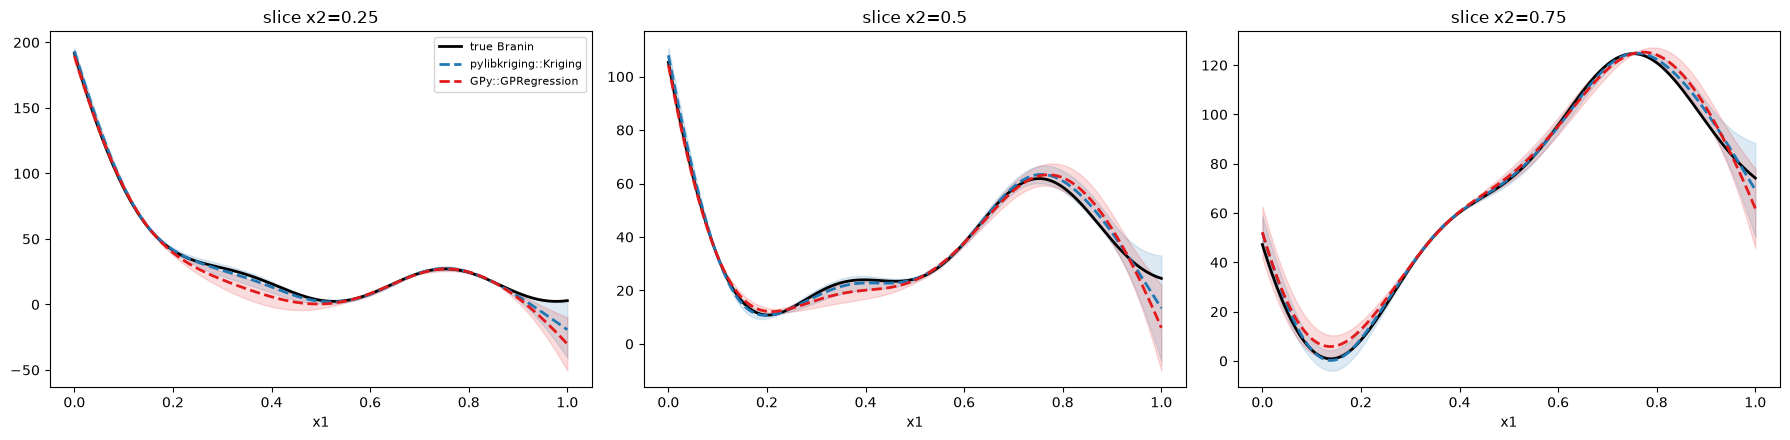

In [6]:
grid = lhs(300, 2, seed=7)
mean_lk = k_lk.predict(grid, True, False, False)[0].flatten()
mean_gpy = m_gpy.predict(grid)[0].flatten()

print("Max |mean_lk - mean_gpy| :", np.max(np.abs(mean_lk - mean_gpy)))
print("Correlation              :", np.corrcoef(mean_lk, mean_gpy)[0, 1])

models_mimicry = [
    ("pylibkriging::Kriging",
     lambda Xs: (k_lk.predict(Xs, True, False, False)[0].flatten(),
                 k_lk.predict(Xs, True, False, False)[1].flatten())),
    ("GPy::GPRegression",
     lambda Xs: (m_gpy.predict(Xs)[0].flatten(),
                 np.sqrt(np.maximum(m_gpy.predict(Xs)[1].flatten(), 0)))),
]
plot_slices(models_mimicry)


Both fits reproduce the same overall predictor: `pylibkriging`'s
`Kriging(kernel="matern5_2", regmodel="constant", objective="LL")` closely
matches the default behaviour of GPy's `GPRegression` with an ARD Matern 5/2
kernel -- the mean curves and uncertainty ribbons overlap almost everywhere,
and the predicted means over 300 random test points are highly correlated
(as for the other notebooks, Branin's multimodal likelihood means the two
independent optimizers do not necessarily land on numerically identical
length-scales).


## 4. Package-specific feature: scaling to many observations

We now use a much larger design ($n=1500$) to compare how each package
handles the cost of scaling Kriging/GP regression to many training points.

* **GPy exact** `GPRegression`: exact Gaussian process, $O(n^3)$ per
  likelihood evaluation.
* **GPy sparse** `SparseGPRegression` (Titsias 2009): a variational
  approximation built from $M=25 \ll n$ inducing points, $O(nM^2)$ per
  evaluation -- trading some accuracy for a much smaller compute budget.
* **plain `pylibkriging::Kriging`**: exact Kriging on the full design, for
  reference.
* **Manually partitioned `pylibkriging::Kriging`**: split the design into 6
  clusters by K-means and fit one independent Kriging submodel per cluster,
  predicting each test point from the submodel of its nearest cluster. This
  mirrors the partition-and-aggregate idea that `NestedKriging` implements
  natively (with a proper probabilistic aggregation of the submodels,
  rather than the simple hard assignment used here) in libKriging's C++,
  R, Octave and Julia interfaces.


In [7]:
import time

n_hd = 1500
X_hd = lhs(n_hd, 2, seed=11)
y_hd = branin(X_hd).reshape(-1, 1)

X_test = lhs(300, 2, seed=13)
y_test = branin(X_test)


def rmse(pred):
    return np.sqrt(np.mean((pred - y_test) ** 2))


timings = {}
accuracies = {}

# --- GPy exact ---
t0 = time.time()
kern_full = GPy.kern.Matern52(2, ARD=True)
m_full = GPy.models.GPRegression(X_hd, y_hd, kern_full, noise_var=1e-6)
m_full.Gaussian_noise.variance.fix(1e-6)
m_full.optimize(messages=False, max_iters=150)
timings["GPy exact"] = time.time() - t0
accuracies["GPy exact"] = rmse(m_full.predict(X_test)[0].flatten())

# --- GPy sparse (M=25 inducing points) ---
M = 25
t0 = time.time()
kern_sp = GPy.kern.Matern52(2, ARD=True)
Z = lhs(M, 2, seed=99)
m_sp = GPy.models.SparseGPRegression(X_hd, y_hd, kern_sp, Z=Z)
m_sp.Gaussian_noise.variance.fix(1e-6)
m_sp.optimize(messages=False, max_iters=150)
timings["GPy sparse (M=25)"] = time.time() - t0
accuracies["GPy sparse (M=25)"] = rmse(m_sp.predict(X_test)[0].flatten())

# --- plain pylibkriging Kriging ---
t0 = time.time()
k_full_lk = lk.Kriging(y_hd.flatten(), X_hd, "matern5_2", regmodel="constant",
                        optim="BFGS", objective="LL")
timings["pylibkriging exact"] = time.time() - t0
accuracies["pylibkriging exact"] = rmse(k_full_lk.predict(X_test, True, False, False)[0].flatten())

# --- manually partitioned pylibkriging Kriging (poor-man's NestedKriging) ---
G = 6
t0 = time.time()
km = KMeans(n_clusters=G, n_init=5, random_state=0).fit(X_hd)
labels = km.labels_
submodels = [
    lk.Kriging(y_hd.flatten()[labels == g], X_hd[labels == g], "matern5_2",
               regmodel="constant", optim="BFGS", objective="LL")
    for g in range(G)
]
timings["pylibkriging partitioned (G=6)"] = time.time() - t0


def predict_partitioned(Xt):
    lab = km.predict(Xt)
    out = np.zeros(len(Xt))
    for g in range(G):
        idx = lab == g
        if idx.sum() > 0:
            out[idx] = submodels[g].predict(Xt[idx], True, False, False)[0].flatten()
    return out


accuracies["pylibkriging partitioned (G=6)"] = rmse(predict_partitioned(X_test))

for name in timings:
    print(f"{name:32s} fit time = {timings[name]:7.2f}s   held-out RMSE = {accuracies[name]:8.4f}")


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


why are your arrays not F order?
why are your arrays not F order?
why are your arrays not F order?


GPy exact                        fit time =   29.48s   held-out RMSE =   0.0003
GPy sparse (M=25)                fit time =    6.51s   held-out RMSE =   0.0346
pylibkriging exact               fit time =    4.66s   held-out RMSE =   0.0004
pylibkriging partitioned (G=6)   fit time =    0.72s   held-out RMSE =   0.0019


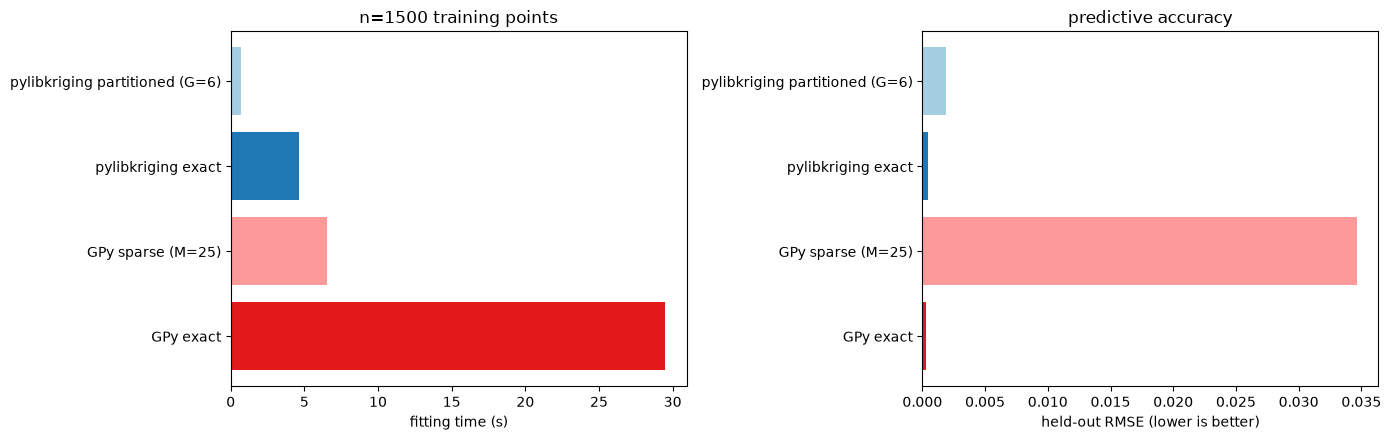

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
names = list(timings.keys())
colors = ["#e31a1c", "#fb9a99", "#1f78b4", "#a6cee3"]

axes[0].barh(names, [timings[k] for k in names], color=colors)
axes[0].set_xlabel("fitting time (s)")
axes[0].set_title(f"n={n_hd} training points")

axes[1].barh(names, [accuracies[k] for k in names], color=colors)
axes[1].set_xlabel("held-out RMSE (lower is better)")
axes[1].set_title("predictive accuracy")

fig.tight_layout()
plt.show()


At $n=1500$, GPy's exact `GPRegression` is the slowest to fit -- it pays
the full $O(n^3)$ cost of an exact Gaussian process. Its sparse
approximation with only $M=25$ inducing points is noticeably faster,
at the cost of a somewhat higher held-out RMSE: exactly the
accuracy/compute trade-off sparse GPs are designed to offer, and the knob
(`M`) that lets a user dial it in. `pylibkriging::Kriging` is already fast
enough in exact form at this size (thanks to its C++/Armadillo core) that
no approximation is strictly necessary here; but the same "many
observations" scaling question is what `NestedKriging` addresses
architecturally, and even our simple, manually partitioned stand-in
(independent Kriging experts per K-means cluster, hard-assigned at
prediction time) is markedly faster than fitting one global model, while
remaining competitive on accuracy -- illustrating why `NestedKriging`'s
proper probabilistic aggregation of local experts is libKriging's own
answer to large-$n$ scalability, playing the same role as GPy's
inducing-point sparse GP.


## 5. Argument correspondence table

| GPy | pylibkriging equivalent | Notes |
|---|---|---|
| `GPy.kern.Matern52(d, ARD=True)` | `kernel="matern5_2"` | pylibkriging's `Kriging` is always ARD (one length-scale per dimension); also `GPy.kern.RBF` -> `"gauss"`, `GPy.kern.Exponential` -> `"exp"`, `GPy.kern.Matern32` -> `"matern3_2"` |
| constant `mean_function` (default: zero mean + separate constant) | `regmodel="constant"` | also `"linear"`, `"quadratic"` |
| `Gaussian_noise.variance` | `noise="nugget"` (on `Kriging`) or a fixed variance vector | GPy's homoscedastic observation noise |
| `GPRegression(X, y, kern)` + `.optimize_restarts(...)` | constructor `Kriging(y, X, ..., optim="BFGS10")` | pylibkriging fits (with restarts) at construction time |
| `.predict(Xnew)` | `.predict(Xnew, return_stdev=True, ...)` | returns `(mean, variance)` in GPy vs `(mean, stdev, ...)` in pylibkriging |
| `SparseGPRegression(X, y, kern, Z=inducing_points)` | *(no direct equivalent)* | closest libKriging answer to large-$n$ scaling is `NestedKriging` (partition-and-aggregate local experts), architecturally different from an inducing-point approximation, and not yet exposed via the Python binding |
| `kern.lengthscale`, `kern.variance` | `.theta()`, `.sigma2()` | different parameterisations of the same Matern kernel |

See `skills/libkriging/SKILL.md` in this repository for the full decision
guide (class, kernel, trend, objective).
